# Geodemographic Clustering Case Study
Test decoding cluster means vs mean of clusters in input space. 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import joblib
import pickle
from sklearn.decomposition import PCA
import torch
from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')


print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu128
CUDA available: True


## Configuration

In [2]:
# Parameters
target_dim = 100
n_clusters = 8  # Match OAC supergroups
n_inits = 10000  # Must match 7a
random_seed = 20210321

# Paths
data_path = "../AE_outputs/engcensus_all/"
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
geo_path = "../data/geofiles/Output_Areas_(December_2021)_Boundaries_EW_BFE_(V9)_and_RUC.geojson"
oac_path = "../data/OAC/OAC_assignment.csv"

# Stability checkpoint path (for median run embeddings and model)
stability_path = f"../AE_outputs/retraining_stability_500epochs_linscaling/data/stability_checkpoint_{target_dim}d.pkl"

# Output directories
plots_dir = "./plots/clustering_plots/"
results_dir = "./clustering_results/"
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

print(f"Creating {n_clusters} clusters from {target_dim}D embeddings (500 EPOCH MEDIAN RUN)")
print(f"Random seed: {random_seed}")
print(f"n_inits: {n_inits}")

Creating 8 clusters from 100D embeddings (500 EPOCH MEDIAN RUN)
Random seed: 20210321
n_inits: 10000


## Load Data

In [3]:
# Load original census data
print("Loading census data...")
df_census = pd.read_parquet(cleaned_data_path)
df_census = df_census.set_index('OA')
print(f"Census data: {df_census.shape}")

# Load PCA embeddings (compute on the fly - deterministic)
print(f"\nComputing PCA {target_dim}D embeddings...")
pca = PCA(n_components=target_dim, random_state=random_seed)
pca_embeddings = pca.fit_transform(df_census)
pca_latent_df = pd.DataFrame(pca_embeddings, index=df_census.index)
print(f"PCA embeddings: {pca_latent_df.shape}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Load AE embeddings from stability checkpoint (500 EPOCH MEDIAN RUN)
print(f"\nLoading stability checkpoint from: {stability_path}")
with open(stability_path, 'rb') as f:
    checkpoint = pickle.load(f)

embeddings_list = checkpoint['embeddings_list']
reco_errors_list = checkpoint['reco_errors_list']
n_runs = checkpoint['n_runs']
print(f"Loaded {n_runs} runs from stability checkpoint")

# Find the median run (by overall RMSE)
rmse_per_run = []
for run_idx, reco_err in enumerate(reco_errors_list):
    rmse = np.sqrt(reco_err.mean()) * 100
    rmse_per_run.append(rmse)

rmse_per_run = np.array(rmse_per_run)
median_rmse = np.median(rmse_per_run)
median_run_idx = np.argmin(np.abs(rmse_per_run - median_rmse))

print(f"\nMedian RMSE: {median_rmse:.4f}%")
print(f"Median run index: {median_run_idx} (RMSE = {rmse_per_run[median_run_idx]:.4f}%)")

# Get median run embeddings
ae_embeddings = embeddings_list[median_run_idx]
ae_latent_df = pd.DataFrame(ae_embeddings, index=df_census.index)
print(f"\nAE embeddings (median run): {ae_latent_df.shape}")

# Load OAC
print(f"\nLoading OAC classifications...")
oac = pd.read_csv(oac_path)
oac = oac[['Geography_Code', 'Supergroup8']].rename(columns={'Geography_Code': 'OA'})
oac = oac.set_index('OA')
oac = oac.reindex(df_census.index)
print(f"OAC: {oac.shape}")
print(f"OAC Supergroups: {oac['Supergroup8'].nunique()} unique groups")

Loading census data...
Census data: (188880, 408)

Computing PCA 100D embeddings...


PCA embeddings: (188880, 100)
Explained variance: 0.984

Loading stability checkpoint from: ../AE_outputs/retraining_stability_500epochs_linscaling/data/stability_checkpoint_100d.pkl


Loaded 10 runs from stability checkpoint

Median RMSE: 0.7931%
Median run index: 5 (RMSE = 0.7925%)

AE embeddings (median run): (188880, 100)

Loading OAC classifications...


OAC: (188880, 1)
OAC Supergroups: 8 unique groups


## Cluster Center Decoding Analysis

**Goal**: Test if averaging in latent space produces meaningful cluster prototypes.

**Method**:
1. Compute cluster centers in latent space (mean of embeddings per cluster)
2. Decode these centers back to 408D:
   - PCA: Use inverse_transform()
   - AE: Pass through decoder network
3. Compare decoded centers vs actual means of original data for each cluster

**Expected Result**:
- PCA should match perfectly (linearity)
- AE may have small discrepancies (non-linearity)
- Small discrepancies → latent space preserves cluster structure well

### Import Autoencoder Architecture

In [4]:
# Import the AutoEncoder class from torchgeodemo package
from torchgeodemo.models import AutoEncoder

print(f"✓ Imported AutoEncoder from torchgeodemo.models")
print(f"  This is the same architecture used to train the models")

✓ Imported AutoEncoder from torchgeodemo.models
  This is the same architecture used to train the models


### Load Trained Autoencoder Model

In [5]:
# Load trained AE model from saved weights (500 EPOCH MEDIAN RUN)
input_dim = df_census.shape[1]  # 408 variables
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Loading model for run {median_run_idx}...")

# Load saved model for the median run
models_dir = "../AE_outputs/retraining_stability_500epochs_linscaling/models/"
model_file = f"{models_dir}/stability_{target_dim}d_run_{median_run_idx}__ae_{target_dim}d_{target_dim}d_run_{median_run_idx}_500ep_v1__model.pth"
print(f"Loading from: {model_file}")

ae_model = torch.load(model_file, map_location=device, weights_only=False)
ae_model = ae_model.to(device)
ae_model.eval()

print(f"Loaded AE model (run {median_run_idx})")
print(f"  Model type: {type(ae_model).__name__}")
print(f"  Device: {device}")

Loading model for run 5...
Loading from: ../AE_outputs/retraining_stability_500epochs_linscaling/models//stability_100d_run_5__ae_100d_100d_run_5_500ep_v1__model.pth
Loaded AE model (run 5)
  Model type: AutoEncoder
  Device: cuda


In [6]:
# Load the kmeans clustering results for AE and PCA embeddings
clustering_file = f"{results_dir}/cluster_assignments_{target_dim}d_k{n_clusters}_n{n_inits}.csv"
pca_model_file = f"{results_dir}/kmeans_pca_{target_dim}d_k{n_clusters}_n{n_inits}.joblib"
ae_model_file = f"{results_dir}/kmeans_ae_{target_dim}d_k{n_clusters}_n{n_inits}.joblib"

print(f"Loading clustering results from {clustering_file}...")
clusters_df = pd.read_csv(clustering_file, index_col=0)
kmeans_pca = joblib.load(pca_model_file)
kmeans_ae = joblib.load(ae_model_file)

pca_clusters = clusters_df['pca_cluster'].values
ae_clusters = clusters_df['ae_cluster'].values

print(f"Loaded {len(clusters_df)} cluster assignments")
print(f"KMeans models loaded from {pca_model_file} and {ae_model_file}")

Loading clustering results from ./clustering_results//cluster_assignments_100d_k8_n10000.csv...


Loaded 188880 cluster assignments
KMeans models loaded from ./clustering_results//kmeans_pca_100d_k8_n10000.joblib and ./clustering_results//kmeans_ae_100d_k8_n10000.joblib


### Compute Cluster Centers in Latent Space

In [7]:
print("Computing cluster centers in latent space...\n")

# Get cluster centers from KMeans (already computed during clustering)
pca_cluster_centers = kmeans_pca.cluster_centers_  # shape: (n_clusters, target_dim)
ae_cluster_centers = kmeans_ae.cluster_centers_    # shape: (n_clusters, target_dim)

print(f"PCA cluster centers: {pca_cluster_centers.shape}")
print(f"AE cluster centers: {ae_cluster_centers.shape}")

# Also compute actual means in original space for each cluster
pca_actual_means = np.zeros((n_clusters, input_dim))
ae_actual_means = np.zeros((n_clusters, input_dim))

for cluster_id in range(n_clusters):
    # PCA cluster actual mean
    pca_mask = pca_clusters == cluster_id
    pca_actual_means[cluster_id] = df_census[pca_mask].mean().values
    
    # AE cluster actual mean
    ae_mask = ae_clusters == cluster_id
    ae_actual_means[cluster_id] = df_census[ae_mask].mean().values

print(f"\nPCA actual means: {pca_actual_means.shape}")
print(f"AE actual means: {ae_actual_means.shape}")

Computing cluster centers in latent space...

PCA cluster centers: (8, 100)
AE cluster centers: (8, 100)



PCA actual means: (8, 408)
AE actual means: (8, 408)


### Decode Cluster Centers Back to Original Space

In [8]:
print("Decoding cluster centers back to 408D...\n")

# PCA: Use inverse_transform
print("PCA inverse transform...")
pca_decoded_centers = pca.inverse_transform(pca_cluster_centers)
print(f"  PCA decoded centers: {pca_decoded_centers.shape}")

# AE: Pass through decoder
print("\nAE decoder...")
with torch.no_grad():
    ae_centers_tensor = torch.FloatTensor(ae_cluster_centers).to(device)
    ae_decoded_centers = ae_model.decoder(ae_centers_tensor).cpu().numpy()
print(f"  AE decoded centers: {ae_decoded_centers.shape}")

print(f"\n✓ Decoded {n_clusters} cluster centers for both methods")

Decoding cluster centers back to 408D...

PCA inverse transform...
  PCA decoded centers: (8, 408)

AE decoder...
  AE decoded centers: (8, 408)

✓ Decoded 8 cluster centers for both methods


### Compute Discrepancy Metrics

In [9]:
print("="*80)
print("CLUSTER CENTER DECODING METRICS")
print("="*80)

# Compute metrics for each cluster
pca_metrics = []
ae_metrics = []

for cluster_id in range(n_clusters):
    # PCA metrics
    pca_decoded = pca_decoded_centers[cluster_id]
    pca_actual = pca_actual_means[cluster_id]
    pca_rmse = np.sqrt(np.mean((pca_decoded - pca_actual)**2))
    pca_corr, _ = pearsonr(pca_decoded, pca_actual)
    pca_metrics.append({'cluster': cluster_id, 'rmse': pca_rmse, 'correlation': pca_corr})
    
    # AE metrics
    ae_decoded = ae_decoded_centers[cluster_id]
    ae_actual = ae_actual_means[cluster_id]
    ae_rmse = np.sqrt(np.mean((ae_decoded - ae_actual)**2))
    ae_corr, _ = pearsonr(ae_decoded, ae_actual)
    ae_metrics.append({'cluster': cluster_id, 'rmse': ae_rmse, 'correlation': ae_corr})

# Convert to DataFrames
pca_metrics_df = pd.DataFrame(pca_metrics)
ae_metrics_df = pd.DataFrame(ae_metrics)

# Overall metrics
pca_mean_rmse = pca_metrics_df['rmse'].mean()
ae_mean_rmse = ae_metrics_df['rmse'].mean()
pca_mean_corr = pca_metrics_df['correlation'].mean()
ae_mean_corr = ae_metrics_df['correlation'].mean()

print(f"\nPCA (decoded center vs actual mean):")
print(f"  Mean RMSE: {pca_mean_rmse:.6f}")
print(f"  Mean Correlation: {pca_mean_corr:.6f}")
print(f"  RMSE range: [{pca_metrics_df['rmse'].min():.6f}, {pca_metrics_df['rmse'].max():.6f}]")
print(f"  Corr range: [{pca_metrics_df['correlation'].min():.6f}, {pca_metrics_df['correlation'].max():.6f}]")

print(f"\nAE (decoded center vs actual mean):")
print(f"  Mean RMSE: {ae_mean_rmse:.6f}")
print(f"  Mean Correlation: {ae_mean_corr:.6f}")
print(f"  RMSE range: [{ae_metrics_df['rmse'].min():.6f}, {ae_metrics_df['rmse'].max():.6f}]")
print(f"  Corr range: [{ae_metrics_df['correlation'].min():.6f}, {ae_metrics_df['correlation'].max():.6f}]")

print(f"\nComparison:")
print(f"  RMSE ratio (AE/PCA): {ae_mean_rmse / pca_mean_rmse:.2f}x")
print(f"  Correlation difference (AE - PCA): {ae_mean_corr - pca_mean_corr:+.6f}")

# Per-cluster breakdown
print(f"\n{'='*80}")
print("PER-CLUSTER METRICS")
print(f"{'='*80}")

comparison_df = pd.DataFrame({
    'Cluster': range(n_clusters),
    'PCA_RMSE': pca_metrics_df['rmse'],
    'AE_RMSE': ae_metrics_df['rmse'],
    'PCA_Corr': pca_metrics_df['correlation'],
    'AE_Corr': ae_metrics_df['correlation']
})
print(comparison_df.to_string(index=False))

# Save metrics
comparison_df.to_csv(f"{results_dir}/cluster_center_decoding_metrics_{target_dim}d.csv", index=False)
print(f"\n✓ Saved metrics to {results_dir}/cluster_center_decoding_metrics_{target_dim}d.csv")

CLUSTER CENTER DECODING METRICS

PCA (decoded center vs actual mean):
  Mean RMSE: 0.000270
  Mean Correlation: 0.999999
  RMSE range: [0.000154, 0.000391]
  Corr range: [0.999998, 1.000000]

AE (decoded center vs actual mean):
  Mean RMSE: 0.003411
  Mean Correlation: 0.999864
  RMSE range: [0.002280, 0.005128]
  Corr range: [0.999664, 0.999954]

Comparison:
  RMSE ratio (AE/PCA): 12.61x
  Correlation difference (AE - PCA): -0.000135

PER-CLUSTER METRICS
 Cluster  PCA_RMSE  AE_RMSE  PCA_Corr  AE_Corr
       0  0.000154 0.002280  1.000000 0.999954
       1  0.000391 0.002743  0.999998 0.999901
       2  0.000230 0.003538  0.999999 0.999864
       3  0.000379 0.003897  0.999998 0.999858
       4  0.000245 0.002810  0.999999 0.999926
       5  0.000162 0.005128  1.000000 0.999664
       6  0.000249 0.003240  0.999999 0.999888
       7  0.000353 0.003651  0.999998 0.999858

✓ Saved metrics to ./clustering_results//cluster_center_decoding_metrics_100d.csv


### Visualization: Per-Cluster RMSE Comparison

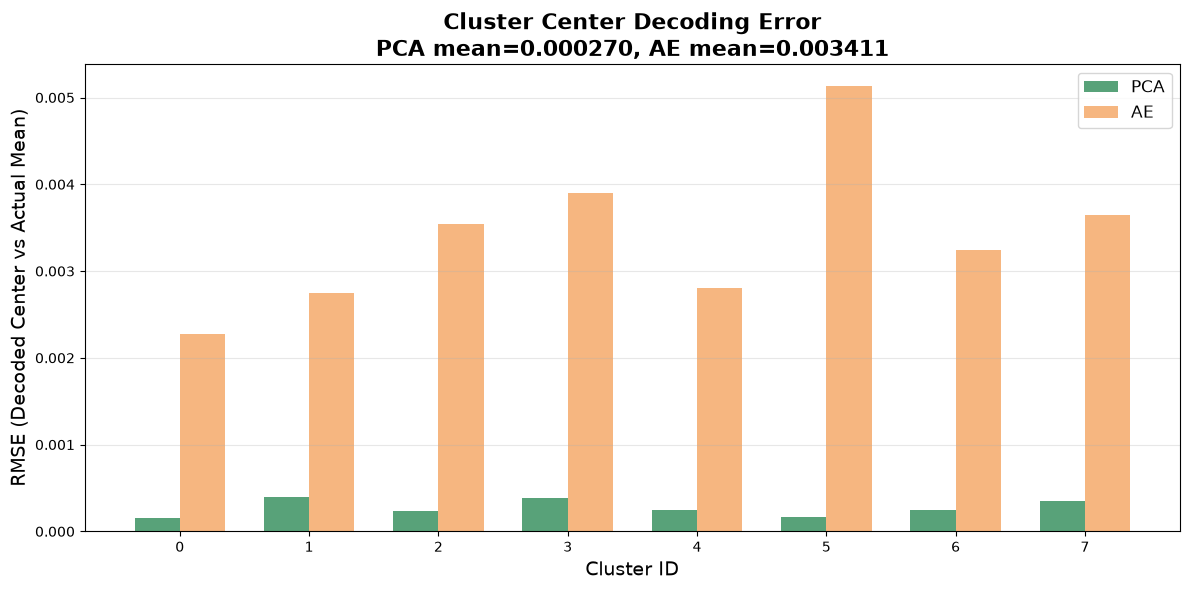

✓ Saved RMSE bar chart


In [10]:
# Bar chart: Per-cluster RMSE
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(n_clusters)
width = 0.35

ax.bar(x - width/2, pca_metrics_df['rmse'], width, label='PCA', color='seagreen', alpha=0.8)
ax.bar(x + width/2, ae_metrics_df['rmse'], width, label='AE', color='sandybrown', alpha=0.8)

ax.set_xlabel('Cluster ID', fontsize=14)
ax.set_ylabel('RMSE (Decoded Center vs Actual Mean)', fontsize=14)
ax.set_title(f'Cluster Center Decoding Error\nPCA mean={pca_mean_rmse:.6f}, AE mean={ae_mean_rmse:.6f}', 
             fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{plots_dir}/cluster_center_rmse_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved RMSE bar chart")

### Visualization: Decoded vs Actual Scatter Plots (First 2 Clusters)

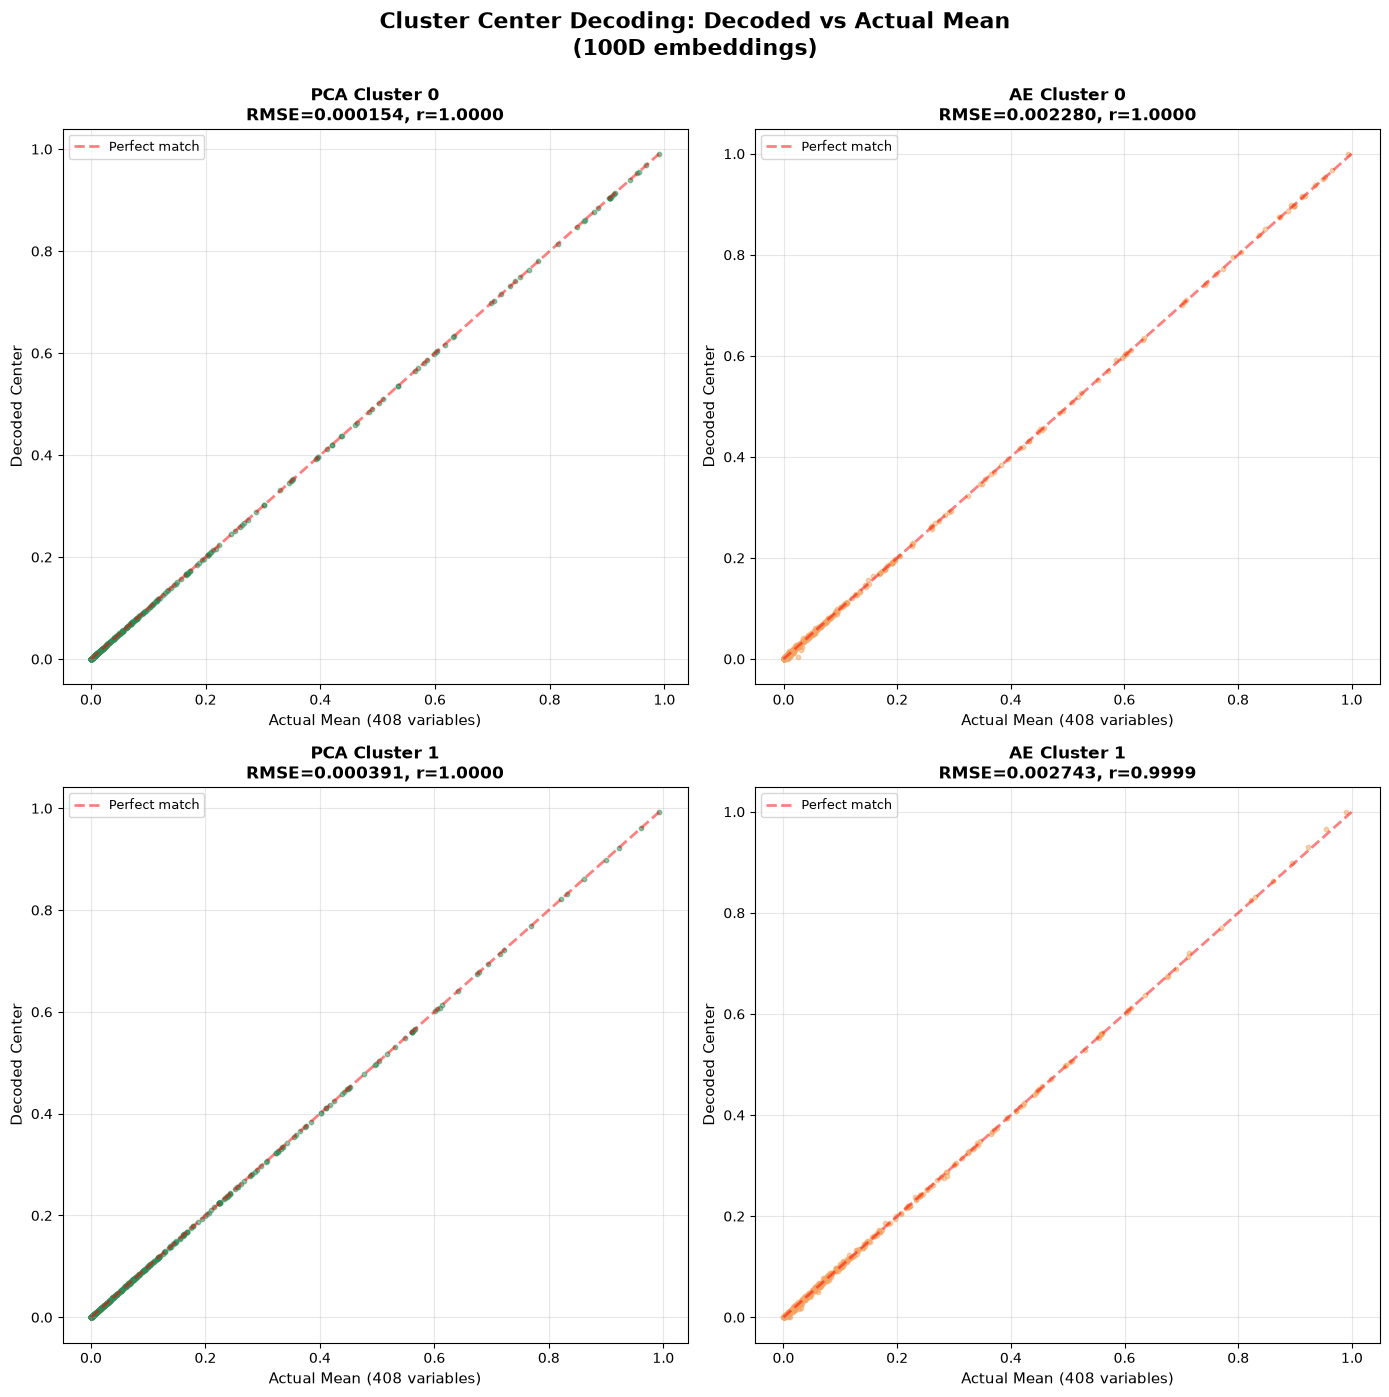

✓ Saved scatter plots


In [11]:
# Scatter plots for first 2 clusters as examples
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for cluster_idx in range(min(2, n_clusters)):
    # PCA
    ax_pca = axes[cluster_idx, 0]
    pca_decoded = pca_decoded_centers[cluster_idx]
    pca_actual = pca_actual_means[cluster_idx]
    
    ax_pca.scatter(pca_actual, pca_decoded, alpha=0.5, s=10, color='seagreen')
    lims = [min(pca_actual.min(), pca_decoded.min()), max(pca_actual.max(), pca_decoded.max())]
    ax_pca.plot(lims, lims, 'r--', alpha=0.5, linewidth=2, label='Perfect match')
    ax_pca.set_xlabel('Actual Mean (408 variables)', fontsize=11)
    ax_pca.set_ylabel('Decoded Center', fontsize=11)
    ax_pca.set_title(f'PCA Cluster {cluster_idx}\nRMSE={pca_metrics_df.iloc[cluster_idx]["rmse"]:.6f}, r={pca_metrics_df.iloc[cluster_idx]["correlation"]:.4f}',
                     fontsize=12, fontweight='bold')
    ax_pca.legend(fontsize=9)
    ax_pca.grid(True, alpha=0.3)
    
    # AE
    ax_ae = axes[cluster_idx, 1]
    ae_decoded = ae_decoded_centers[cluster_idx]
    ae_actual = ae_actual_means[cluster_idx]
    
    ax_ae.scatter(ae_actual, ae_decoded, alpha=0.5, s=10, color='sandybrown')
    lims = [min(ae_actual.min(), ae_decoded.min()), max(ae_actual.max(), ae_decoded.max())]
    ax_ae.plot(lims, lims, 'r--', alpha=0.5, linewidth=2, label='Perfect match')
    ax_ae.set_xlabel('Actual Mean (408 variables)', fontsize=11)
    ax_ae.set_ylabel('Decoded Center', fontsize=11)
    ax_ae.set_title(f'AE Cluster {cluster_idx}\nRMSE={ae_metrics_df.iloc[cluster_idx]["rmse"]:.6f}, r={ae_metrics_df.iloc[cluster_idx]["correlation"]:.4f}',
                     fontsize=12, fontweight='bold')
    ax_ae.legend(fontsize=9)
    ax_ae.grid(True, alpha=0.3)

plt.suptitle(f'Cluster Center Decoding: Decoded vs Actual Mean\n({target_dim}D embeddings)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f"{plots_dir}/cluster_center_scatter_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved scatter plots")